In [7]:
from backtesting.test import SMA

from backtesting import Strategy
from backtesting.lib import crossover


class Sma4Cross(Strategy):
    n1 = 50
    n2 = 100
    n_enter = 20
    n_exit = 10
    
    def init(self):
        self.sma1 = self.I(SMA, self.data.Close, self.n1)
        self.sma2 = self.I(SMA, self.data.Close, self.n2)
        self.sma_enter = self.I(SMA, self.data.Close, self.n_enter)
        self.sma_exit = self.I(SMA, self.data.Close, self.n_exit)
        
    def next(self):
        
        if not self.position:
            
            # On upwards trend, if price closes above
            # "entry" MA, go long
            
            # Here, even though the operands are arrays, this
            # works by implicitly comparing the two last values
            if self.sma1 > self.sma2:
                if crossover(self.data.Close, self.sma_enter):
                    self.buy()
                    
            # On downwards trend, if price closes below
            # "entry" MA, go short
            
            else:
                if crossover(self.sma_enter, self.data.Close):
                    self.sell()
        
        # But if we already hold a position and the price
        # closes back below (above) "exit" MA, close the position
        
        else:
            if (self.position.is_long and
                crossover(self.sma_exit, self.data.Close)
                or
                self.position.is_short and
                crossover(self.data.Close, self.sma_exit)):
                
                self.position.close()


from backtesting import Backtest
from backtesting.test import GOOG

print(GOOG)
backtest = Backtest(GOOG, Sma4Cross, commission=.002)

stats, heatmap = backtest.optimize(
    n1=range(10, 110, 10),
    n2=range(20, 210, 20),
    n_enter=range(15, 35, 5),
    n_exit=range(10, 25, 5),
    constraint=lambda p: p.n_exit < p.n_enter < p.n1 < p.n2,
    maximize='Equity Final [$]',
    max_tries=200,
    random_state=0,
    return_heatmap=True)

              Open    High     Low   Close    Volume
2004-08-19  100.00  104.06   95.96  100.34  22351900
2004-08-20  101.01  109.08  100.50  108.31  11428600
2004-08-23  110.75  113.48  109.05  109.40   9137200
2004-08-24  111.24  111.60  103.57  104.87   7631300
2004-08-25  104.96  108.00  103.88  106.00   4598900
...            ...     ...     ...     ...       ...
2013-02-25  802.30  808.41  790.49  790.77   2303900
2013-02-26  795.00  795.95  784.40  790.13   2202500
2013-02-27  794.80  804.75  791.11  799.78   2026100
2013-02-28  801.10  806.99  801.03  801.20   2265800
2013-03-01  797.80  807.14  796.15  806.19   2175400

[2148 rows x 5 columns]


c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\backtesting.py:1639: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\backtesting.py:1652: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\backtesting.py:1652: UserWarni

In [5]:
heatmap
heatmap.sort_values().iloc[-3:]
hm = heatmap.groupby(['n1', 'n2']).mean().unstack()
hm = hm[::-1]
hm

n2,40,60,80,100,120,140,160,180,200
n1,,,,,,,,,
100,NaN,NaN,NaN,NaN,9694.916433,6494.395120,10063.312100,9010.021340,10301.052040
90,NaN,NaN,NaN,8275.004560,8427.478907,8540.802240,8771.714470,9646.891040,7884.190400
80,NaN,NaN,NaN,9477.030585,6846.677987,8042.726640,7919.793820,9096.508892,7900.527500
70,NaN,NaN,12498.792160,6417.253460,9069.628160,9034.698500,7384.788047,8576.842730,8286.385476
60,NaN,NaN,8027.698710,7129.254833,9436.619620,11145.884807,9273.167873,8484.339020,8491.336050
50,NaN,7501.18579,8909.361084,9270.710655,8017.689713,12118.288310,11939.279045,10091.097520,8868.400580
40,NaN,12103.33798,NaN,6930.314820,9295.272070,11125.635940,9847.437933,9538.793860,9331.124125
30,12386.32272,10224.43572,10360.192190,13537.819300,11160.573660,9967.153670,9841.654180,9882.299655,9331.487872
20,NaN,8448.64150,8348.383380,9283.020760,NaN,NaN,NaN,NaN,NaN


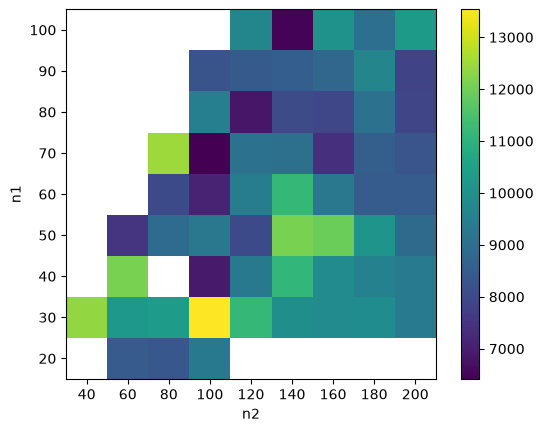

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
im = ax.imshow(hm, cmap='viridis')
_ = (
    ax.set_xticks(range(len(hm.columns)), labels=hm.columns),
    ax.set_yticks(range(len(hm)), labels=hm.index),
    ax.set_xlabel('n2'),
    ax.set_ylabel('n1'),
    ax.figure.colorbar(im, ax=ax),
)

In [12]:
import pandas as pd

# start_date = '2023-1-1 00:00'
# end_date = '2024-3-29 00:00'
start_date = '2026-1-1 00:00'
end_date = '2026-9-16 00:00'
# start_date = '2022-01-1 00:00'
# end_date = '2026-9-16 00:00'
pair = 'GBPJPY'
timezone = "Europe/London"

df_h4_raw = pd.read_csv(f"../Trading Data/{pair}_H4.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_m15_raw = pd.read_csv(f"../Trading Data/{pair}_M15.csv",sep=',', parse_dates=['Date'], index_col='Date')

df_h4 = df_h4_raw.loc['2021-10-1 00:00' : end_date]

backtest = Backtest(df_h4, Sma4Cross, commission=.002)

stats, heatmap = backtest.optimize(
    n1=range(10, 110, 10),
    n2=range(20, 210, 20),
    n_enter=range(15, 35, 5),
    n_exit=range(10, 25, 5),
    constraint=lambda p: p.n_exit < p.n_enter < p.n1 < p.n2,
    maximize='Return [%]',
    max_tries=200,
    random_state=0,
    return_heatmap=True)

c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\backtesting.py:1639: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\backtesting.py:1652: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\backtesting.py:1652: UserWarni

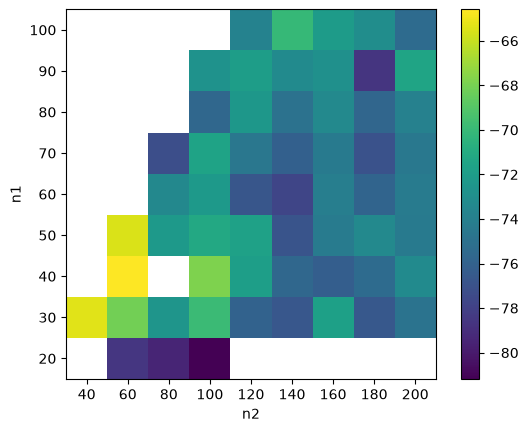

In [13]:
import matplotlib.pyplot as plt

heatmap
heatmap.sort_values().iloc[-3:]
hm = heatmap.groupby(['n1', 'n2']).mean().unstack()
hm = hm[::-1]
hm

fig, ax = plt.subplots()
im = ax.imshow(hm, cmap='viridis')
_ = (
    ax.set_xticks(range(len(hm.columns)), labels=hm.columns),
    ax.set_yticks(range(len(hm)), labels=hm.index),
    ax.set_xlabel('n2'),
    ax.set_ylabel('n1'),
    ax.figure.colorbar(im, ax=ax),
)